In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("heart.csv")

In [4]:
print(data.shape, data.dtypes, data.isna(), data.describe())

(1025, 14) age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object         age    sex     cp  trestbps   chol    fbs  restecg  thalach  exang  \
0     False  False  False     False  False  False    False    False  False   
1     False  False  False     False  False  False    False    False  False   
2     False  False  False     False  False  False    False    False  False   
3     False  False  False     False  False  False    False    False  False   
4     False  False  False     False  False  False    False    False  False   
...     ...    ...    ...       ...    ...    ...      ...      ...    ...   
1020  False  False  False     False  False  False    False    False  False   
1021  False  False  False     False  False  False    False    False  Fa

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
data.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


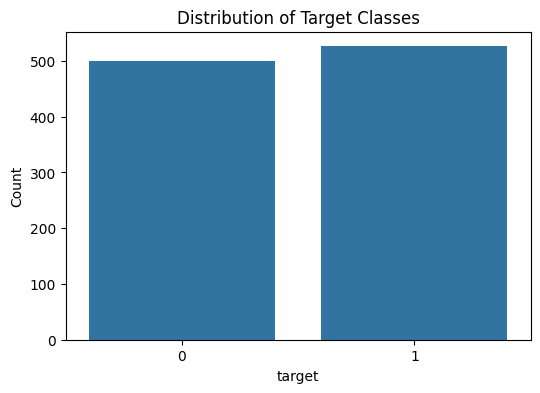

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(6,4))
sns.countplot(x='target', data=data)

plt.title("Distribution of Target Classes")
plt.xlabel("target")
plt.ylabel("Count")
plt.show()

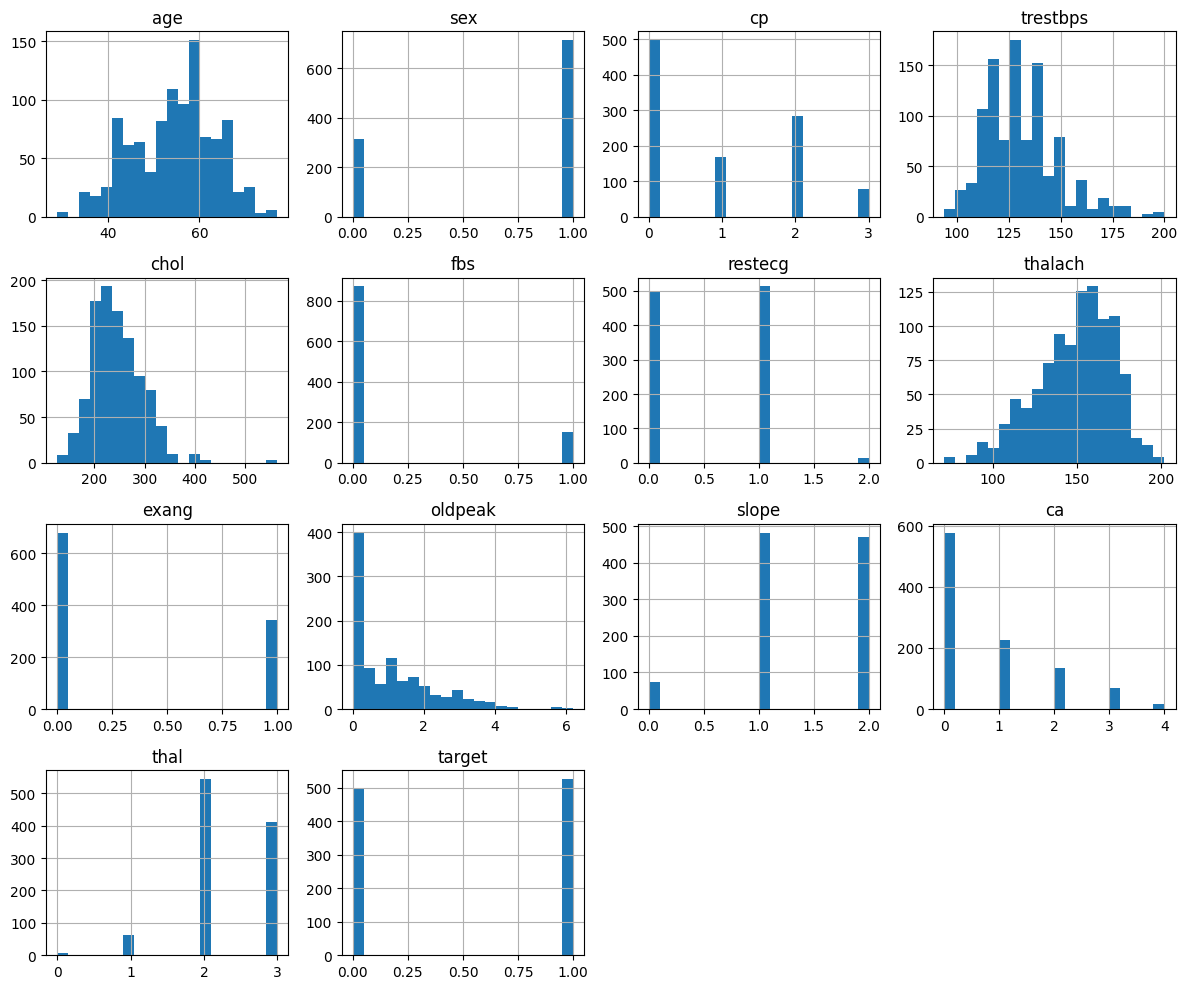

In [12]:
data.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

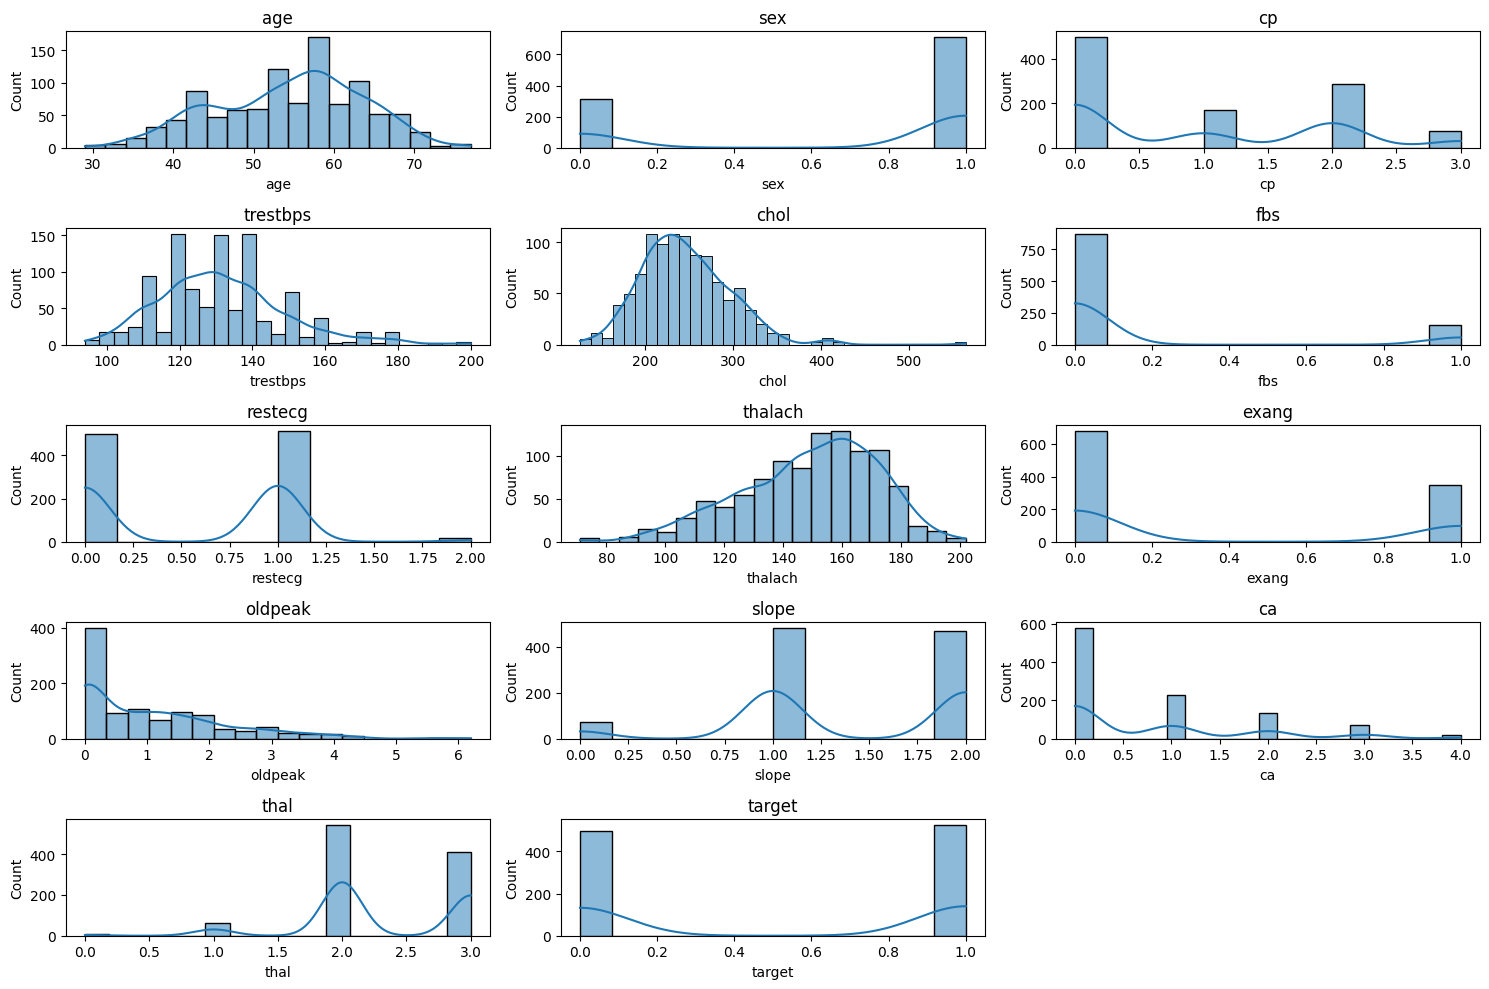

In [11]:
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15,10))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns)//3 + 1, 3, i)
    sns.histplot(data[column], kde=True)
    plt.title(column)

plt.tight_layout()
plt.show()

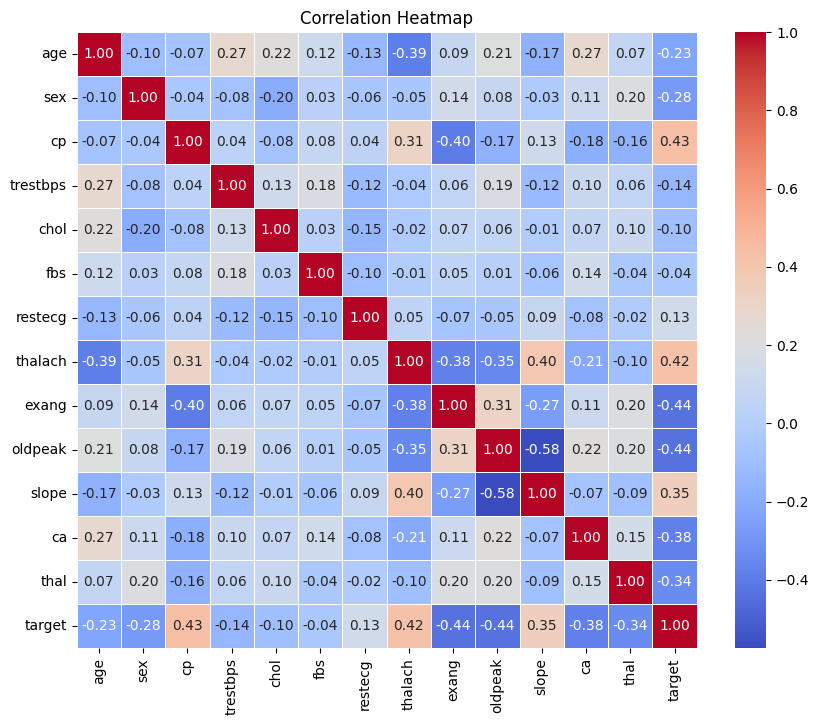

In [13]:
plt.figure(figsize=(10,8))

correlation_matrix = data.corr()

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

X = data.drop(columns=['target'])
y = data['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

        age       sex        cp  trestbps      chol       fbs   restecg  \
0 -0.268437  0.661504 -0.915755 -0.377636 -0.659332 -0.418878  0.891255   
1 -0.158157  0.661504 -0.915755  0.479107 -0.833861  2.387330 -1.004049   
2  1.716595  0.661504 -0.915755  0.764688 -1.396233 -0.418878  0.891255   
3  0.724079  0.661504 -0.915755  0.936037 -0.833861 -0.418878  0.891255   
4  0.834359 -1.511706 -0.915755  0.364875  0.930822  2.387330  0.891255   

    thalach     exang   oldpeak     slope        ca      thal  
0  0.821321 -0.712287 -0.060888  0.995433  1.209221  1.089852  
1  0.255968  1.403928  1.727137 -2.243675 -0.731971  1.089852  
2 -1.048692  1.403928  1.301417 -2.243675 -0.731971  1.089852  
3  0.516900 -0.712287 -0.912329  0.995433  0.238625  1.089852  
4 -1.874977 -0.712287  0.705408 -0.624121  2.179817 -0.522122  


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.25,random_state=42)

In [22]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=50000)

logreg.fit(X_train,y_train)

LogisticRegression(max_iter=50000)

In [24]:
y_pred = logreg.predict(X_test)

In [25]:
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test,y_pred)
cnf_matrix

array([[ 96,  36],
       [ 18, 107]])

In [27]:
print("Accuracy:", metrics.accuracy_score(y_test,y_pred) )
print("Precision:", metrics.precision_score(y_test,y_pred) )
print("Recall:", metrics.recall_score(y_test,y_pred) )
print("F1:", metrics.f1_score(y_test,y_pred) )
print("ROC-AUC:", metrics.roc_auc_score(y_test,y_pred) )

Accuracy: 0.7898832684824902
Precision: 0.7482517482517482
Recall: 0.856
F1: 0.7985074626865671
ROC-AUC: 0.7916363636363636
